# Quantization Attack Evaluation (Appendix F.2)

This notebook reproduces the **Appendix F.2 quantization attack** experiment on the models trained in this repo.

Unlike the paper table, this notebook does **not** use Gemma-2-2B. It evaluates the locally trained **EleutherAI/pythia-160m** TOFU models:

| Family | Method | Checkpoint |
|---|---|---|
| MaxEnt | Unlearned | `models/maxent/pythia-160m-unlearned` |
| MaxEnt | Unlearned + Distilled | `models/maxent/pythia-160m-distilled` |
| UNDO | Unlearned | `models/undo/pythia-160m-unlearned` |
| UNDO | Unlearned + Distilled | `models/undo/pythia-160m-distilled` |

Each checkpoint is evaluated in:

- **FP16**
- **INT4 / NF4 quantized** via `bitsandbytes`

Metrics reported:

- **Forget Q&A Prob** — lower is better
- **Forget Truth Ratio** — lower is better
- **Model Utility** — higher is better

## 1. Setup

In [25]:
import os
import gc
import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


REPO_DIR = Path("/lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Repo   : {REPO_DIR}")
print(f"Device : {DEVICE}")
print(f"Torch  : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Repo   : /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338
Device : cuda
Torch  : 2.4.0
GPU    : NVIDIA H100 80GB HBM3


## 2. Configuration

In [26]:
BASE_MODEL_ID = "EleutherAI/pythia-160m"

MODELS_DIR = Path("/lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models")

MODEL_CONFIGS = [
    {
        "family": "Baseline",
        "method": "Pretrained (no fine-tuning)",
        "path": BASE_MODEL_ID,   # HuggingFace Hub — never saw TOFU data
        "distilled": False,
        "fp16_only": True,       # no need to quantize the baseline
    },
    {
        "family": "MaxEnt",
        "method": "MaxEnt",
        "path": MODELS_DIR / "maxent/pythia-160m-unlearned",
        "distilled": False,
    },
    {
        "family": "MaxEnt",
        "method": "MaxEnt + Distilled",
        "path": MODELS_DIR / "maxent/pythia-160m-distilled",
        "distilled": True,
    },
    # {
    #     "family": "UNDO",
    #     "method": "UNDO",
    #     "path": MODELS_DIR / "undo/pythia-160m-unlearned",
    #     "distilled": False,
    # },
    {
        "family": "UNDO",
        "method": "UNDO",
        "path": MODELS_DIR / "undo/pythia-160m-distilled",
        "distilled": True,
    },
]

TOFU_FORGET_SPLIT = "forget10"
TOFU_RETAIN_SPLIT = "retain90"

# Use 25 for smoke test; set to None for full evaluation.
MAX_EVAL_SAMPLES = None

MAX_LENGTH = 512

print("Checkpoint status:")
for cfg in MODEL_CONFIGS:
    p = cfg["path"]
    if isinstance(p, str):
        status = "HUB "
    elif Path(str(p)).is_dir() and (Path(str(p)) / "config.json").exists():
        status = "OK  "
    else:
        status = "MISS"
    fp16_only = " [FP16 only]" if cfg.get("fp16_only") else ""
    print(f"[{status}] {cfg['method']:<30} {p}{fp16_only}")


Checkpoint status:
[HUB ] Pretrained (no fine-tuning)    EleutherAI/pythia-160m [FP16 only]
[OK  ] MaxEnt                         /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-unlearned
[OK  ] MaxEnt + Distilled             /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/maxent/pythia-160m-distilled
[OK  ] UNDO                           /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/models/undo/pythia-160m-distilled


## 3. Load TOFU Evaluation Splits

In [27]:
import json as _json

FORGET_SPLIT_PATH = REPO_DIR / "notebooks/attacks/forget10_split.json"

_full_forget_ds = load_dataset("locuslab/TOFU", TOFU_FORGET_SPLIT, split="train")
retain_ds       = load_dataset("locuslab/TOFU", TOFU_RETAIN_SPLIT, split="train")

if FORGET_SPLIT_PATH.exists():
    split_info = _json.loads(FORGET_SPLIT_PATH.read_text())
    assert split_info["tofu_split"] == TOFU_FORGET_SPLIT, \
        f"Split file is for {split_info['tofu_split']}, expected {TOFU_FORGET_SPLIT}"
    forget_ds = _full_forget_ds.select(split_info["train_indices"])
    print(f"Loaded forget-train-half from split file (seed={split_info['seed']})")
    print(f"  {len(forget_ds)} / {len(_full_forget_ds)} forget examples (train half — held-out half reserved for MIA)")
else:
    print(f"WARNING: {FORGET_SPLIT_PATH} not found.")
    print("Run the experiments-undo.ipynb split cell first to generate the train/held-out split.")
    print("Falling back to full forget10.")
    forget_ds = _full_forget_ds

if MAX_EVAL_SAMPLES is not None:
    forget_ds = forget_ds.select(range(min(MAX_EVAL_SAMPLES, len(forget_ds))))
    retain_ds = retain_ds.select(range(min(MAX_EVAL_SAMPLES, len(retain_ds))))

print(f"Forget eval samples : {len(forget_ds)}")
print(f"Retain eval samples : {len(retain_ds)}")


Loaded forget-train-half from split file (seed=42)
  200 / 400 forget examples (train half — held-out half reserved for MIA)
Forget eval samples : 200
Retain eval samples : 3600


## 4. Model Loading Helpers

In [28]:
def get_int4_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )


def validate_checkpoint(model_path):
    # Do NOT call .resolve() — it can mangle Lustre/NFS mount paths.
    model_path = Path(model_path)

    if not model_path.is_dir():
        raise FileNotFoundError(f"Checkpoint directory does not exist: {model_path}")

    if not (model_path / "config.json").exists():
        files = sorted(p.name for p in model_path.iterdir())
        raise FileNotFoundError(
            f"Checkpoint exists but has no config.json: {model_path}\n"
            f"Files: {files}"
        )

    return model_path


def load_tokenizer(model_path):
    is_hub = isinstance(model_path, str) and not Path(model_path).exists()
    if is_hub:
        tokenizer = AutoTokenizer.from_pretrained(model_path, padding_side="left")
    else:
        model_path = validate_checkpoint(model_path)
        try:
            tokenizer = AutoTokenizer.from_pretrained(
                str(model_path),
                padding_side="left",
                local_files_only=True,
            )
        except Exception as e:
            print(f"Local tokenizer not found; using {BASE_MODEL_ID}. Reason: {e}")
            tokenizer = AutoTokenizer.from_pretrained(
                BASE_MODEL_ID,
                padding_side="left",
            )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return tokenizer


def load_model(model_path, precision):
    is_hub = isinstance(model_path, str) and not Path(model_path).exists()
    tokenizer = load_tokenizer(model_path)

    if not is_hub:
        model_path = validate_checkpoint(model_path)

    load_kwargs = {} if is_hub else {"local_files_only": True, "trust_remote_code": True}

    if precision == "INT4":
        if not torch.cuda.is_available():
            raise RuntimeError("INT4 bitsandbytes quantization requires CUDA.")

        model = AutoModelForCausalLM.from_pretrained(
            str(model_path),
            quantization_config=get_int4_config(),
            device_map="auto",
            **load_kwargs,
        )

    elif precision == "FP16":
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        model = AutoModelForCausalLM.from_pretrained(
            str(model_path),
            torch_dtype=dtype,
            device_map="auto" if torch.cuda.is_available() else None,
            **load_kwargs,
        )

        if not torch.cuda.is_available():
            model.to("cpu")

    else:
        raise ValueError(f"Unknown precision: {precision}")

    model.eval()
    return model, tokenizer


def cleanup_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 5. Metric Helpers

In [29]:
def model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def answer_log_prob(model, tokenizer, question, answer, max_length=MAX_LENGTH):
    prompt = f"Question: {question}\nAnswer: "
    full_text = prompt + str(answer)

    full = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    prompt_only = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )

    input_ids = full["input_ids"].to(model_device(model))
    attention_mask = full.get("attention_mask")
    if attention_mask is not None:
        attention_mask = attention_mask.to(model_device(model))

    labels = input_ids.clone()
    prompt_len = prompt_only["input_ids"].shape[1]
    labels[:, :prompt_len] = -100

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    )

    # Negative mean NLL over answer tokens.
    return -float(outputs.loss.item())


def evaluate_split(model, tokenizer, dataset, split_name):
    log_probs = []

    for i, ex in enumerate(dataset):
        lp = answer_log_prob(
            model,
            tokenizer,
            ex["question"],
            ex["answer"],
        )
        log_probs.append(lp)

        if (i + 1) % 100 == 0:
            print(f"  {split_name}: {i + 1}/{len(dataset)}")

    log_probs = np.array(log_probs, dtype=np.float64)
    probs = np.exp(log_probs)

    return {
        f"{split_name}_mean_log_prob": float(log_probs.mean()),
        f"{split_name}_qa_prob": float(probs.mean()),
    }


def evaluate_model(model, tokenizer, forget_ds, retain_ds):
    forget = evaluate_split(model, tokenizer, forget_ds, "forget")
    retain = evaluate_split(model, tokenizer, retain_ds, "retain")

    forget_truth_ratio = np.exp(
        forget["forget_mean_log_prob"] - retain["retain_mean_log_prob"]
    )

    return {
        "Forget Q&A Prob": forget["forget_qa_prob"],
        "Forget Truth Ratio": float(forget_truth_ratio),
        "Model Utility": retain["retain_qa_prob"],
    }

## 6. Run FP16 and INT4 Evaluations

In [30]:
results = []

for cfg in MODEL_CONFIGS:
    precisions = ["FP16"] if cfg.get("fp16_only") else ["FP16", "INT4"]

    for precision in precisions:
        print("=" * 80)
        print(f"Evaluating {cfg['method']} [{cfg['family']}] at {precision}")
        print(f"Path: {cfg['path']}")
        print("=" * 80)

        try:
            model, tokenizer = load_model(cfg["path"], precision)
            metrics = evaluate_model(model, tokenizer, forget_ds, retain_ds)

            row = {
                "Family": cfg["family"],
                "Method": cfg["method"],
                "Precision": precision,
                **metrics,
            }
            results.append(row)

            print(row)

            cleanup_model(model)

        except Exception as e:
            print(f"FAILED: {cfg['method']} {precision}: {e}")
            results.append({
                "Family": cfg["family"],
                "Method": cfg["method"],
                "Precision": precision,
                "Forget Q&A Prob": np.nan,
                "Forget Truth Ratio": np.nan,
                "Model Utility": np.nan,
                "Error": str(e),
            })

df = pd.DataFrame(results)
df


Evaluating Pretrained (no fine-tuning) [Baseline] at FP16
Path: EleutherAI/pythia-160m


  forget: 100/200
  forget: 200/200
  retain: 100/3600
  retain: 200/3600
  retain: 300/3600
  retain: 400/3600
  retain: 500/3600
  retain: 600/3600
  retain: 700/3600
  retain: 800/3600
  retain: 900/3600
  retain: 1000/3600
  retain: 1100/3600
  retain: 1200/3600
  retain: 1300/3600
  retain: 1400/3600
  retain: 1500/3600
  retain: 1600/3600
  retain: 1700/3600
  retain: 1800/3600
  retain: 1900/3600
  retain: 2000/3600
  retain: 2100/3600
  retain: 2200/3600
  retain: 2300/3600
  retain: 2400/3600
  retain: 2500/3600
  retain: 2600/3600
  retain: 2700/3600
  retain: 2800/3600
  retain: 2900/3600
  retain: 3000/3600
  retain: 3100/3600
  retain: 3200/3600
  retain: 3300/3600
  retain: 3400/3600
  retain: 3500/3600
  retain: 3600/3600
{'Family': 'Baseline', 'Method': 'Pretrained (no fine-tuning)', 'Precision': 'FP16', 'Forget Q&A Prob': 0.08127432777118677, 'Forget Truth Ratio': 0.9853130765245771, 'Model Utility': 0.08234405459962572}
Evaluating MaxEnt [MaxEnt] at FP16
Path: /lustre

,Family,Method,Precision,Forget Q&A Prob,Forget Truth Ratio,Model Utility
0,Baseline,Pretrained (no fine-tuning),FP16,0.081274,0.985313,0.082344
1,MaxEnt,MaxEnt,FP16,0.000933,0.002003,0.408357
2,MaxEnt,MaxEnt,INT4,0.001167,0.002810,0.365230
3,MaxEnt,MaxEnt + Distilled,FP16,0.224344,0.505159,0.435255
4,MaxEnt,MaxEnt + Distilled,INT4,0.186469,0.504090,0.367391
5,UNDO,UNDO,FP16,0.172619,0.482600,0.340954
6,UNDO,UNDO,INT4,0.149914,0.479025,0.300894


## 7. Appendix F.2-Style Results Table

In [31]:
display_df = df.copy()

for col in ["Forget Q&A Prob", "Forget Truth Ratio", "Model Utility"]:
    display_df[col] = display_df[col].astype(float).round(3)

display_df = display_df[
    ["Family", "Method", "Precision", "Forget Q&A Prob", "Forget Truth Ratio", "Model Utility"]
]

display(display_df)

print("Lower Forget Q&A Prob and Forget Truth Ratio indicate better unlearning.")
print("Higher Model Utility indicates better retained capability.")

,Family,Method,Precision,Forget Q&A Prob,Forget Truth Ratio,Model Utility
0,Baseline,Pretrained (no fine-tuning),FP16,0.081,0.985,0.082
1,MaxEnt,MaxEnt,FP16,0.001,0.002,0.408
2,MaxEnt,MaxEnt,INT4,0.001,0.003,0.365
3,MaxEnt,MaxEnt + Distilled,FP16,0.224,0.505,0.435
4,MaxEnt,MaxEnt + Distilled,INT4,0.186,0.504,0.367
5,UNDO,UNDO,FP16,0.173,0.483,0.341
6,UNDO,UNDO,INT4,0.150,0.479,0.301


Lower Forget Q&A Prob and Forget Truth Ratio indicate better unlearning.
Higher Model Utility indicates better retained capability.


## 8. Quantization Degradation Analysis

In [32]:
delta_rows = []

for (family, method), group in df.groupby(["Family", "Method"]):
    fp16 = group[group["Precision"] == "FP16"]
    int4 = group[group["Precision"] == "INT4"]

    if len(fp16) == 0 or len(int4) == 0:
        continue

    fp16 = fp16.iloc[0]
    int4 = int4.iloc[0]

    delta_rows.append({
        "Family": family,
        "Method": method,
        "Δ Forget Q&A Prob": int4["Forget Q&A Prob"] - fp16["Forget Q&A Prob"],
        "Δ Forget Truth Ratio": int4["Forget Truth Ratio"] - fp16["Forget Truth Ratio"],
        "Δ Model Utility": int4["Model Utility"] - fp16["Model Utility"],
    })

delta_df = pd.DataFrame(delta_rows)
display(delta_df.round(3))

,Family,Method,Δ Forget Q&A Prob,Δ Forget Truth Ratio,Δ Model Utility
0,MaxEnt,MaxEnt,0.000,0.001,-0.043
1,MaxEnt,MaxEnt + Distilled,-0.038,-0.001,-0.068
2,UNDO,UNDO,-0.023,-0.004,-0.040


## 9. Visualization

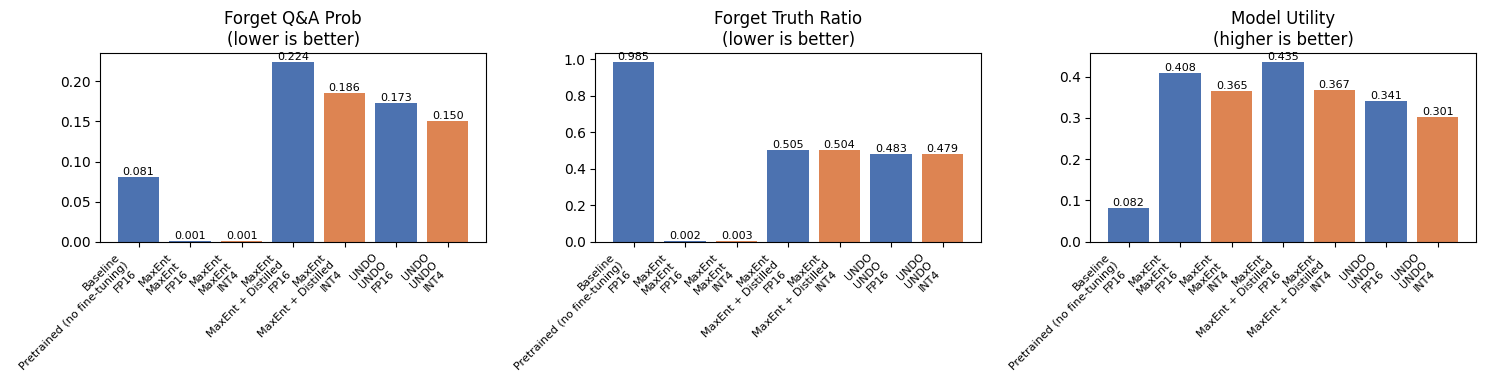

Saved figure to: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/table14_pythia160m_quantization_attack.png


In [ ]:
plot_df = display_df.dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("Forget Q&A Prob", "lower is better"),
    ("Forget Truth Ratio", "lower is better"),
    ("Model Utility", "higher is better"),
]

for ax, (metric, subtitle) in zip(axes, metrics):
    labels = [
        # f"{row.Family}\n{row.Method}\n{row.Precision}"
        f"{row.Method}\n{row.Precision}"
        for row in plot_df.itertuples()
    ]
    values = plot_df[metric].values

    colors = ["#4C72B0" if p == "FP16" else "#DD8452" for p in plot_df["Precision"]]
    ax.bar(range(len(values)), values, color=colors)
    ax.set_title(f"{metric}\n({subtitle})")
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

fig_path = REPO_DIR / "notebooks/attacks/results/table14_pythia160m_quantization_attack.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

In [34]:
# Inspect UNDO + Distilled training logs if available
import os

undo_distilled_path = MODELS_DIR / "undo/pythia-160m-distilled"

# Check for trainer_state.json (HuggingFace saves this)
trainer_state = undo_distilled_path / "trainer_state.json"
if trainer_state.exists():
    with open(trainer_state) as f:
        state = json.load(f)
    print("Final train loss:", state["log_history"][-1])
    print("Last 5 log entries:")
    for entry in state["log_history"][-5:]:
        print(" ", entry)
else:
    print("No trainer_state.json found — check training logs manually")
    print("Files:", sorted(p.name for p in undo_distilled_path.iterdir()))

No trainer_state.json found — check training logs manually
Files: ['config.json', 'generation_config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json']


## 10. Save Results

In [35]:
out_dir = REPO_DIR / "notebooks/attacks/results"
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "table14_pythia160m_results.csv"
json_path = out_dir / "table14_pythia160m_results.json"

df.to_csv(csv_path, index=False)

with open(json_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved CSV : {csv_path}")
print(f"Saved JSON: {json_path}")

Saved CSV : /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/table14_pythia160m_results.csv
Saved JSON: /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/MSandE338/notebooks/attacks/results/table14_pythia160m_results.json


## Notes

This notebook mirrors Appendix F.2 conceptually but evaluates the repo's trained **Pythia-160M** checkpoints instead of Gemma-2-2B.

Interpretation:

- If INT4 increases **Forget Q&A Prob** or **Forget Truth Ratio**, quantization is recovering some forgotten information.
- If distilled models show smaller INT4 degradation than non-distilled models, that supports the Appendix F.2 hypothesis that distillation is more robust to quantization-based recovery.